# Testing Sparse Auto Encoder (SAE)

In principal, it should be possible to extract hidden feature vectors from embedding outputs using a sparse auto-encoder (SAE) to disentangle the superimposed features for a given set of neural activation outputs. To test the validity of using a SAE for this purpose, the code below trains one on some randomized vectors to assess whether the methods described in literature are enough to create sparsity in the feature layer of a 2-layer autoencoder.

In [14]:
# imports
import tensorflow as tf
import keras
from keras import layers
import numpy as np
import Bio
import transformers
from objects.autoencoder import SparseAutoEncoder

# data vis packages
import seaborn as sns
import matplotlib.pyplot as plt

### Train the Model

In [15]:
# create dataset from random tensors to test
SAE_name = 'autoencoder_test'
embed_length = 2048
ef = 4

print("=== Generating Test Data ===")
fake_embeddings = tf.random.uniform(shape=[10000, embed_length])
fake_dataset = tf.data.Dataset.from_tensor_slices((fake_embeddings, fake_embeddings)).batch(100)

print("=== Initializing Model ===")
# initialize the optimizer
optimizer = keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.98,
                                     epsilon=1e-9)

# initialize the loss function
loss = keras.losses.MeanSquaredError()

# initialize the metrics
metrics = [
    keras.metrics.MeanSquaredError(),
    keras.metrics.KLDivergence(),
]

# compile the model
autoencoder = SparseAutoEncoder(encoding_size=embed_length, expansion_factor=ef)
autoencoder.compile(optimizer=optimizer, loss=loss, metrics=metrics)

print(autoencoder.summary())

tb_callback = keras.callbacks.TensorBoard(log_dir=f'./logs/{SAE_name}', histogram_freq=5)
early_stopping = keras.callbacks.EarlyStopping(
    monitor='mean_squared_error',
    min_delta=0.001,
    patience=10, 
    restore_best_weights=True
    )

print("=== Training Model ===")
history = autoencoder.fit(fake_dataset, epochs=100, callbacks=[tb_callback, early_stopping])
print("=== Saving Model ===")
path = f'./models/{SAE_name}.keras'
#autoencoder.save(f'./models/{SAE_name}.keras')
keras.models.save_model(autoencoder, path)
print(f"Model saved to: {path}")
print(autoencoder.summary())

=== Generating Test Data ===
=== Initializing Model ===


Model: "sparse_auto_encoder_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 100,700,162 (384.14 MB)

 Trainable params: 33,566,720 (128.05 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 67,133,442 (256.09 MB)

None


### Examine Weights and their Distribution

Note that in a real use case we would expect most features to have relatively low weights (roughly corresponding to the feature's importance), however, in this case we observe a somewhat sine-like distribution with a bit of decay. I suspect this is due to the process of random number generation, but further analysis would be warranted before asserting that claim.

As a note to myself, the concept of superposition shares a lot of common principles with slit experiments and waves so this particular graph might actually warrant some further investigation from a purely mathematical standpoint. 

In [16]:
feat_weights = np.array(autoencoder.weights[2])
print(f"maximum: {max(feat_weights)}")
print(f"minimum: {min(feat_weights)}")

maximum: -0.02326144091784954
minimum: -0.31331467628479004


/tmp/ipykernel_48187/1965811903.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  feat_weights = np.array(autoencoder.weights[2])


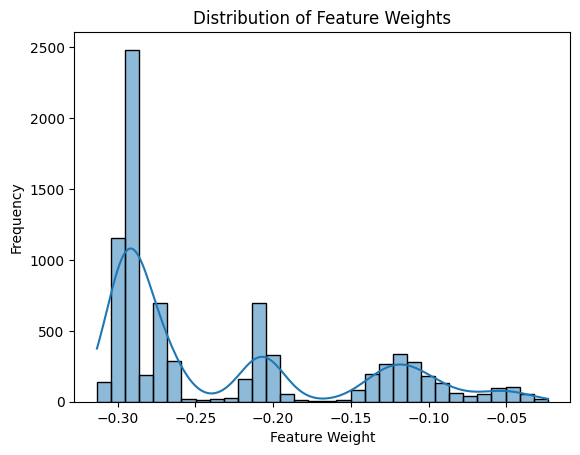

In [17]:
sns.histplot(feat_weights, kde=True)
plt.title('Distribution of Feature Weights')
plt.xlabel('Feature Weight')
plt.ylabel('Frequency')
plt.show()

### Examining Feature Layer for Sparsity

In [18]:
autoencoder.predict_on_batch(fake_embeddings[:100])

(array([[0.5104572 , 0.49872565, 0.5015219 , ..., 0.48731664, 0.49700567,
         0.50285435],
        [0.5126056 , 0.50104666, 0.5040879 , ..., 0.48850408, 0.49996325,
         0.50620186],
        [0.50935596, 0.4970695 , 0.49983096, ..., 0.48556972, 0.49476543,
         0.5002022 ],
        ...,
        [0.51126635, 0.49876714, 0.50155187, ..., 0.48729664, 0.49796277,
         0.50307286],
        [0.50957686, 0.49795523, 0.5005072 , ..., 0.48571548, 0.49522468,
         0.50099146],
        [0.51695704, 0.50300264, 0.50805795, ..., 0.4917613 , 0.5051992 ,
         0.5122535 ]], dtype=float32),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32))

In [19]:
reconstructed_outputs, feature_outputs = autoencoder.predict_on_batch(fake_embeddings[:100])

In [20]:
reconstructed_outputs

array([[0.5104572 , 0.49872565, 0.5015219 , ..., 0.48731664, 0.49700567,
        0.50285435],
       [0.5126056 , 0.50104666, 0.5040879 , ..., 0.48850408, 0.49996325,
        0.50620186],
       [0.50935596, 0.4970695 , 0.49983096, ..., 0.48556972, 0.49476543,
        0.5002022 ],
       ...,
       [0.51126635, 0.49876714, 0.50155187, ..., 0.48729664, 0.49796277,
        0.50307286],
       [0.50957686, 0.49795523, 0.5005072 , ..., 0.48571548, 0.49522468,
        0.50099146],
       [0.51695704, 0.50300264, 0.50805795, ..., 0.4917613 , 0.5051992 ,
        0.5122535 ]], dtype=float32)

In [21]:
feature_outputs

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [22]:
feature_outputs[0].sort()
print(feature_outputs[0][-20:])
print(feature_outputs.shape)

[0.01688114 0.01846281 0.02013281 0.02212864 0.02304751 0.0245409
 0.02591681 0.02720958 0.02999747 0.03085795 0.03150436 0.03159562
 0.03365031 0.03408882 0.03493977 0.03557509 0.04167002 0.04221576
 0.04249194 0.04415798]
(100, 8192)


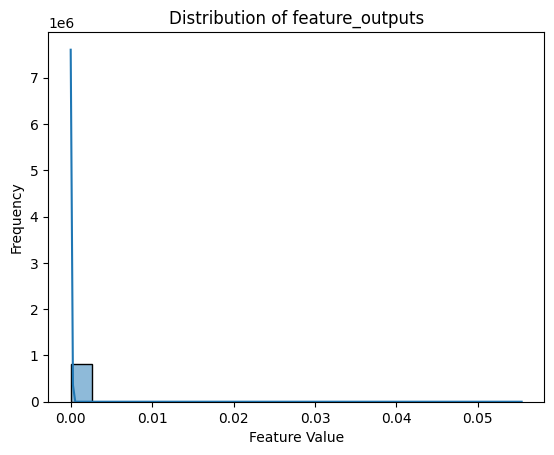

In [23]:
sns.histplot(feature_outputs.flatten(), kde=True)
plt.title('Distribution of feature_outputs')
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.show()

### Check Model Fit / Overfit

In [24]:
# check model fit
fit_test_data = tf.random.uniform(shape=[100, embed_length])
fit_test_dataset = tf.data.Dataset.from_tensor_slices((fit_test_data, fit_test_data)).batch(10)

fit_test = autoencoder.evaluate(fit_test_dataset)
print(f"Loss: {fit_test[0]} | MSE: {fit_test[1]}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 133.3036 - mean_squared_error: 0.0833
Loss: 133.3018798828125 | MSE: 0.08338220417499542


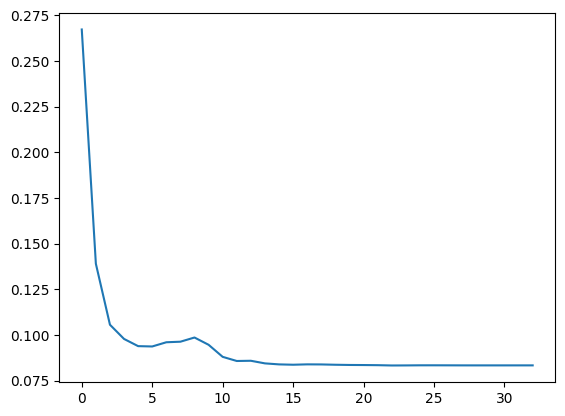

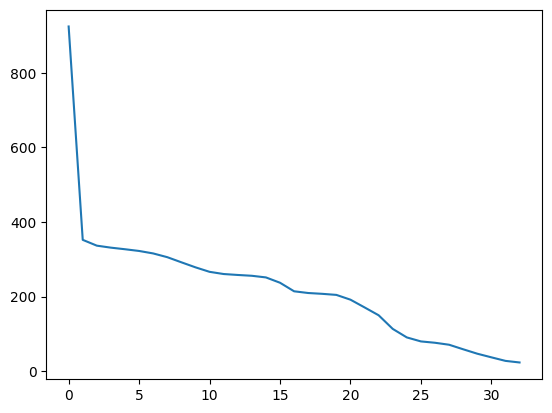

In [25]:
import matplotlib.pyplot as plt

plt.plot(history.history['mean_squared_error'])
plt.show()
plt.plot(history.history['loss'])
plt.show()